<a href="https://colab.research.google.com/github/neelaropp/Fake-News-Classifier/blob/main/capstone_working.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import dask.dataframe as dd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import kagglehub
import os
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn import svm
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from textblob import TextBlob
from transformers import BertTokenizer, TFBertForSequenceClassification, InputExample, InputFeatures, create_optimizer, TFBertModel
import tensorflow as tf
from datasets import Dataset
import joblib
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
# Download the dataset using kagglehub
# Dask Data Set
path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Path to dataset files:", path)

pd_fake_df = pd.read_csv(os.path.join(path, "Fake.csv"))
pd_real_df = pd.read_csv(os.path.join(path, "True.csv"))
combined_df = pd.concat([pd_fake_df, pd_real_df])

# Load CSVs with Dask
fake_df = dd.read_csv(os.path.join(path, "Fake.csv"))
real_df = dd.read_csv(os.path.join(path, "True.csv"))

# Add binary labels
fake_df = fake_df.assign(label=0)
real_df = real_df.assign(label=1)

# Merge datasets
df = dd.concat([fake_df, real_df])

# Shuffle
df = df.random_split([1.0])[0]  # This randomly splits entire data for shuffling
df = df.persist()  #keeps the data in memory for faster access/ don't want to overuse

# Trigger computation
#print(df.head())

Path to dataset files: /kaggle/input/fake-and-real-news-dataset


In [ ]:
pd_fake_df.shape

(23481, 4)

In [ ]:
pd_real_df.shape

(21417, 4)

In [ ]:
combined_df.shape

(44898, 4)

In [ ]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [ ]:
# df.tail()

In [ ]:
# Drop rows with missing text or title
df = df.dropna(subset=["title", "text"])

# Reset index
df = df.reset_index(drop=True)

# get schema and sample rows
print("Dask DataFrame dtypes:\n", df.dtypes)
#print("\nSample rows:\n", df.head())  # Triggers computation just for preview


Dask DataFrame dtypes:
 title      string[pyarrow]
text       string[pyarrow]
subject    string[pyarrow]
date       string[pyarrow]
label                int64
dtype: object


In [ ]:
# Convert title and text to lowercase
df = df.assign(
    title=df["title"].str.lower(),
    text=df["text"].str.lower()
)

In [ ]:
def clean_text_simple(text):
    if not isinstance(text, str):
        return ""

    # Remove "http" or "www" links
    for token in text.split():
        if token.startswith("http") or token.startswith("www"):
            text = text.replace(token, "")

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove digits
    text = ''.join([char for char in text if not char.isdigit()])

    # Strip extra whitespace
    text = " ".join(text.split())

    return text.lower()

df = df.assign(
    title_cleaned=df.map_partitions(lambda part: part["title"].apply(clean_text_simple)),
    text_cleaned=df.map_partitions(lambda part: part["text"].apply(clean_text_simple))
)

# Preview result
#df[["title_cleaned", "text_cleaned"]].head()


In [ ]:
# Load once globally
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_partition(partition):
    try:
        def clean_texts(texts):
            try:
                # Process in batch
                docs = list(nlp.pipe(texts, batch_size=32, disable=["ner", "parser"]))
                cleaned = []
                for doc in docs:
                    try:
                        tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
                        cleaned.append(" ".join(tokens))
                    except Exception as e:
                        cleaned.append("")  # fallback
                return cleaned
            except Exception as e:
                print("Batch-level error:", e)
                return [""] * len(texts)

        partition = partition.copy()
        partition["title_cleaned"] = clean_texts(partition["title"].fillna("").astype(str))
        partition["text_cleaned"] = clean_texts(partition["text"].fillna("").astype(str))

        return partition
    except Exception as e:
        print("Partition-level error:", e)
        return partition

# Optionally sample for testing
sample_df = df.sample(frac=0.05, random_state=42)

# Apply to Dask DataFrame (start small)
cleaned_df = sample_df.map_partitions(clean_partition)

# Trigger preview
#print(cleaned_df[["title_cleaned", "text_cleaned"]].head())

# takes about a minute to run


In [ ]:
def combine_partition(partition): # combining the title and text columns into one column
    try:
        partition = partition.copy()
        partition["combined"] = (
            partition["title_cleaned"].fillna("").astype(str) + " " +
            partition["text_cleaned"].fillna("").astype(str)
        )
        return partition
    except Exception as e:
        print("Error in combine_partition:", e)
        partition["combined"] = ""
        return partition

# Apply safely using map_partitions
df = df.map_partitions(combine_partition)

# Trigger preview to compute just one partition
#print(df[["combined"]].head())


In [ ]:
# Keep only the specified columns
df = df[["label", "title_cleaned", "text_cleaned", "subject", "date", "combined"]]
#df.head()

In [ ]:
# Load spaCy model ONCE globally (outside the partition function)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def clean_partition_combined(partition):
    try:
        def final_cleaning_spacy_optimized(texts):
            cleaned_texts = []
            try:
                docs = nlp.pipe(texts, batch_size=50)
                for doc in docs:
                    try:
                        tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
                        cleaned_texts.append(" ".join(tokens))
                    except Exception as e:
                        cleaned_texts.append("")  # Fallback for broken doc
                return cleaned_texts
            except Exception as e:
                print("spaCy pipe error:", e)
                return [""] * len(texts)

        partition = partition.copy()
        partition["cleaned"] = final_cleaning_spacy_optimized(
            partition["combined"].fillna("").astype(str)
        )
        return partition
    except Exception as e:
        print("Partition-level error in clean_partition_combined:", e)
        partition["cleaned"] = ""
        return partition

# Apply to Dask
df = df.map_partitions(clean_partition_combined)

# Preview
# print(df[["cleaned"]].head())

# this takes 8 minutes to run (if you want to preview your data to make sure it works)


In [ ]:
def filter_short_cleaned(partition):
    try:
        partition = partition.copy()
        # Fill NaNs, strip whitespace, then check length
        partition["cleaned"] = partition["cleaned"].fillna("").astype(str)
        partition = partition[partition["cleaned"].str.strip().str.len() > 10]
        return partition
    except Exception as e:
        print("Error in filter_short_cleaned:", e)
        return partition.iloc[0:0]  # return empty DataFrame on error

# Apply with map_partitions
df = df.map_partitions(filter_short_cleaned)

# Preview
# print(df[["cleaned"]].head())

# This takes 8 minutes to run (if you want to preview your data to make sure it works )


In [ ]:
# Keep only the specified columns
df = df[["label", "title_cleaned", "text_cleaned", "subject", "date", "cleaned"]]

# Persist the result in memory for faster access later
#df = df.persist()

# Quick check to confirm
#print(df.head())

# takes 12 minutes to run

In [ ]:
# df.head()

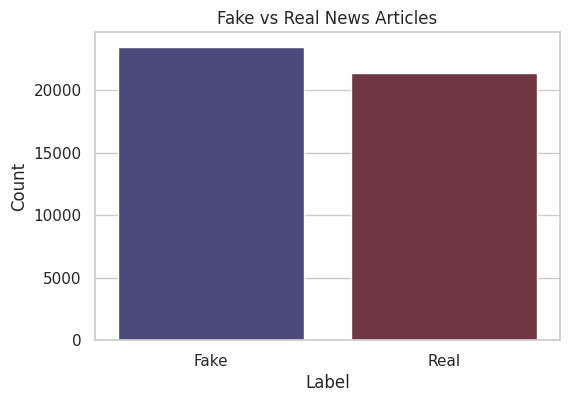

In [ ]:
# Compute and convert to pandas
df_pd = df[["label"]].compute()

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_pd, palette="icefire")
plt.title("Fake vs Real News Articles")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Fake", "Real"])
plt.show()

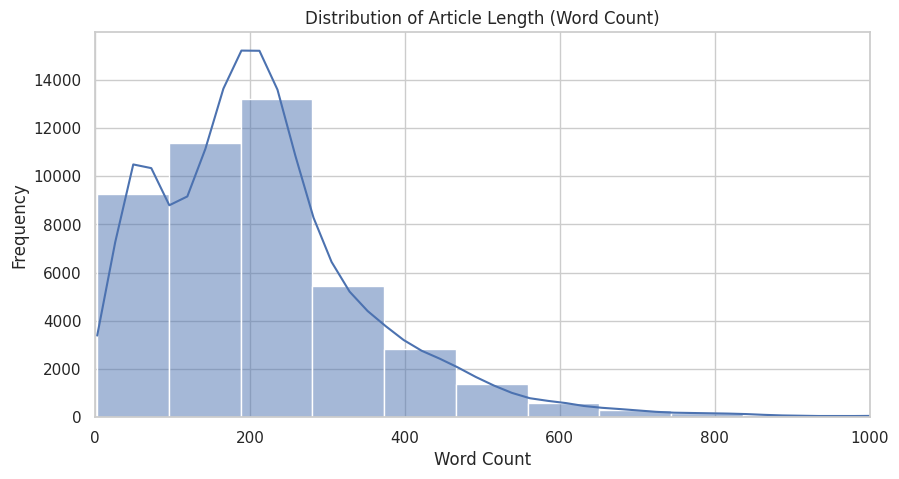

In [ ]:
# Create the word count column using Dask
df["word_count"] = df["cleaned"].map(lambda x: len(x.split()), meta=("word_count", "int"))

#Convert only needed columns to Pandas
df_pd = df[["word_count"]].compute()

#Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_pd["word_count"], bins=50, kde=True, palette="icefire")
plt.title("Distribution of Article Length (Word Count)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 1000)
plt.show()

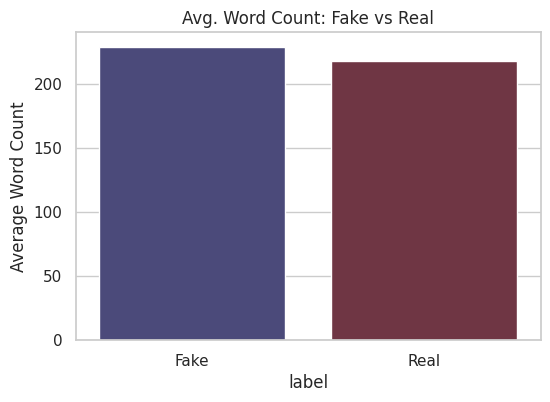

In [ ]:
# using Dask
avg_word_count = df.groupby("label")["word_count"].mean().compute()

# Plot Results
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_word_count.index, y=avg_word_count.values, palette="icefire")
plt.xticks([0, 1], ["Fake", "Real"])
plt.ylabel("Average Word Count")
plt.title("Avg. Word Count: Fake vs Real")
plt.show()

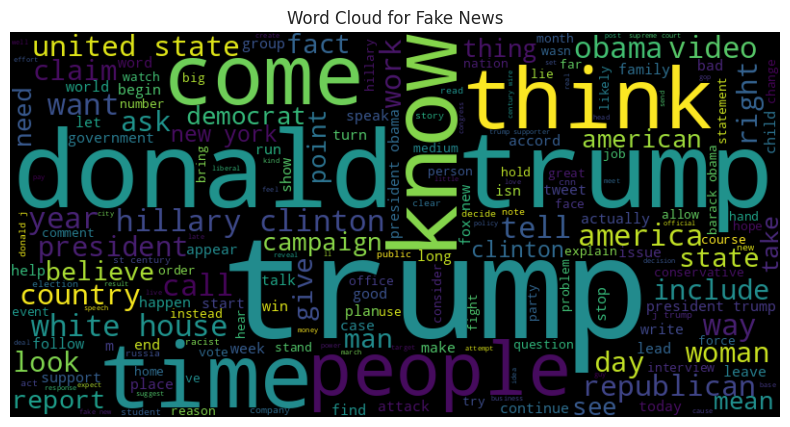

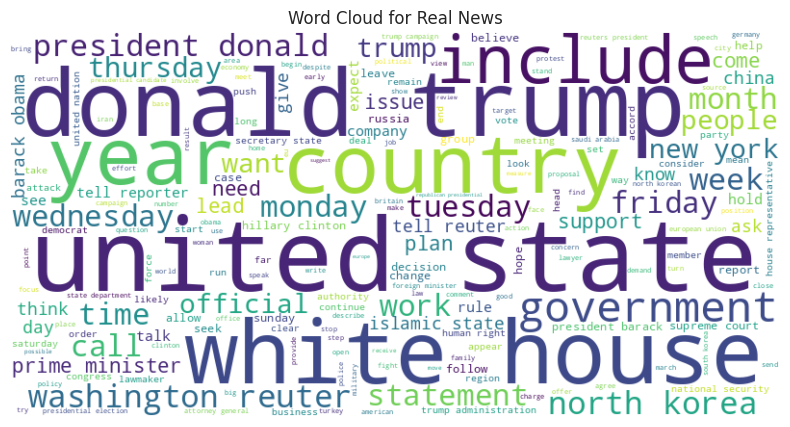

In [ ]:
def plot_wordcloud(label, title, color="white"):
    # Filter and compute cleaned text for the given label
    subset = df[df["label"] == label][["cleaned"]].compute()

    # Join all cleaned text into one string
    text = " ".join(subset["cleaned"].dropna())

    # Define stopwords
    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update(["s", "dont", "go", "say", 't', "don", "didn", "doesn", "add"])  # Add extras as needed if they keep popping up

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color=color,
        colormap="viridis",
        stopwords=custom_stopwords
    ).generate(text)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

# Generate the word clouds
plot_wordcloud(0, "Word Cloud for Fake News", color="black")
plot_wordcloud(1, "Word Cloud for Real News", color="white")


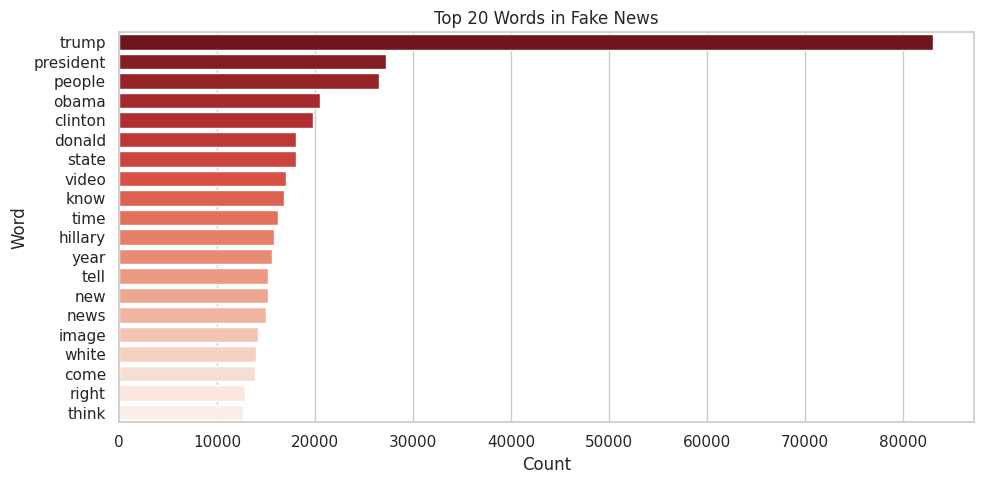

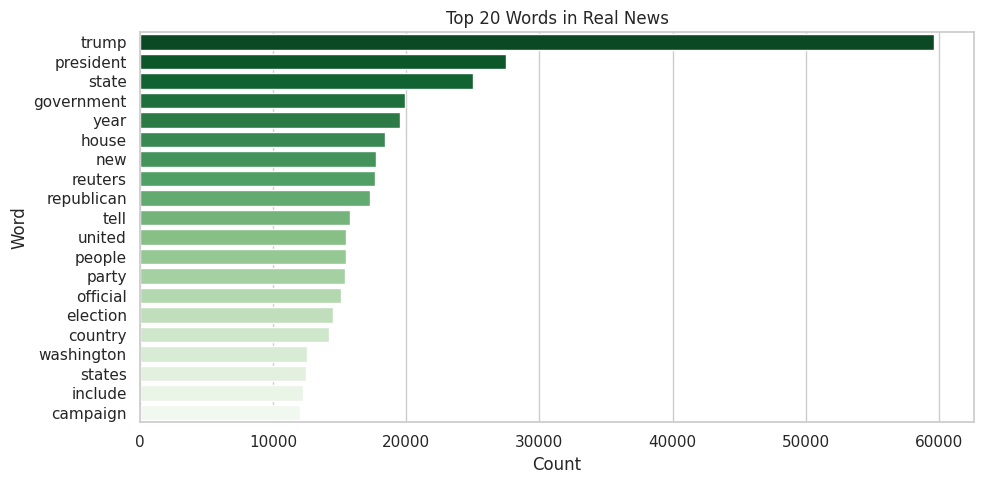

In [ ]:
# Define stopwords
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["s", "t", "say", "also", "go", "like", "dont", "go", "don", "didn", "doesn", "add" ])  # Add more if needed

# Helper to get top N words, excluding stopwords
def get_top_n_words(label, n=20):
    # Compute the filtered subset from Dask
    subset = df[df["label"] == label][["cleaned"]].compute()
    text = " ".join(subset["cleaned"].dropna())

    # Tokenize and filter stopwords
    words = [word for word in text.split() if word.lower() not in custom_stopwords]

    # Count word frequencies
    counter = Counter(words)
    return counter.most_common(n)

# Get top words
fake_top_words = get_top_n_words(0)
real_top_words = get_top_n_words(1)

# Convert to DataFrame for plotting
fake_df = pd.DataFrame(fake_top_words, columns=["word", "count"])
real_df = pd.DataFrame(real_top_words, columns=["word", "count"])

# Plot Fake News
plt.figure(figsize=(10, 5))
sns.barplot(data=fake_df, x="count", y="word", palette="Reds_r")
plt.title("Top 20 Words in Fake News")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

# Plot Real News
plt.figure(figsize=(10, 5))
sns.barplot(data=real_df, x="count", y="word", palette="Greens_r")
plt.title("Top 20 Words in Real News")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


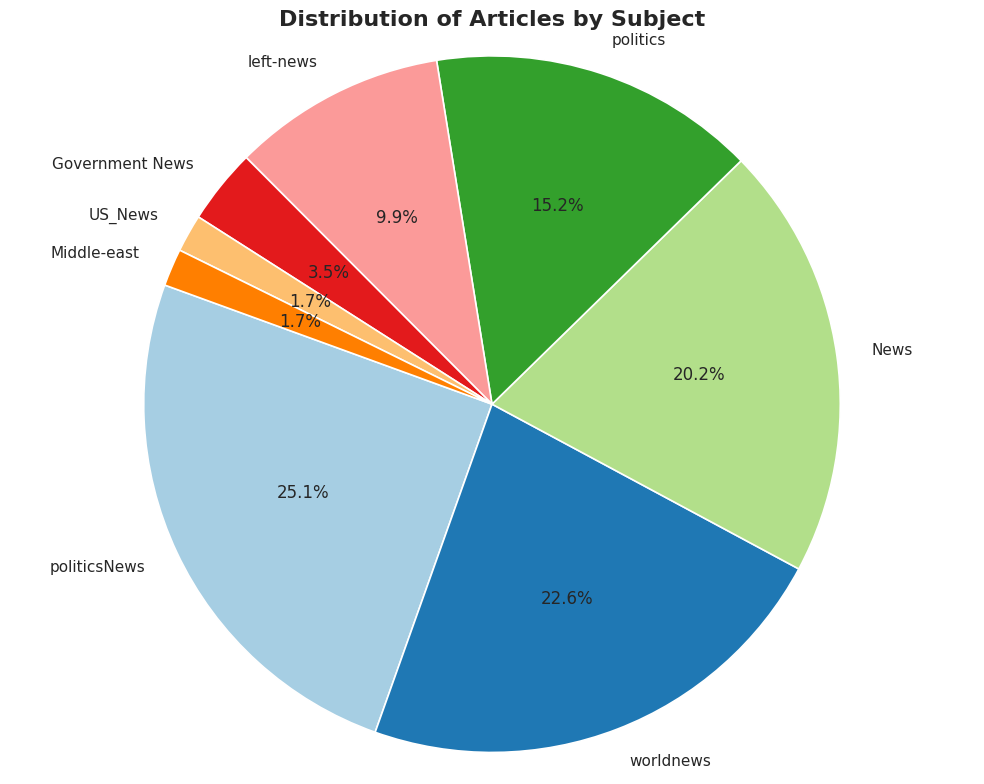

In [ ]:
#Extract needed columns
subject_combined = df[["subject", "label"]].compute()

#Count and sort subjects
subject_counts = subject_combined["subject"].value_counts()

# Set colors
colors = plt.cm.Paired(range(len(subject_counts)))

# pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    subject_counts,
    labels=subject_counts.index,
    autopct="%1.1f%%",
    startangle=160,
    shadow=False,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2}
)
plt.title("Distribution of Articles by Subject", fontsize=16, fontweight='bold')
plt.axis("equal")
plt.tight_layout()
plt.show()


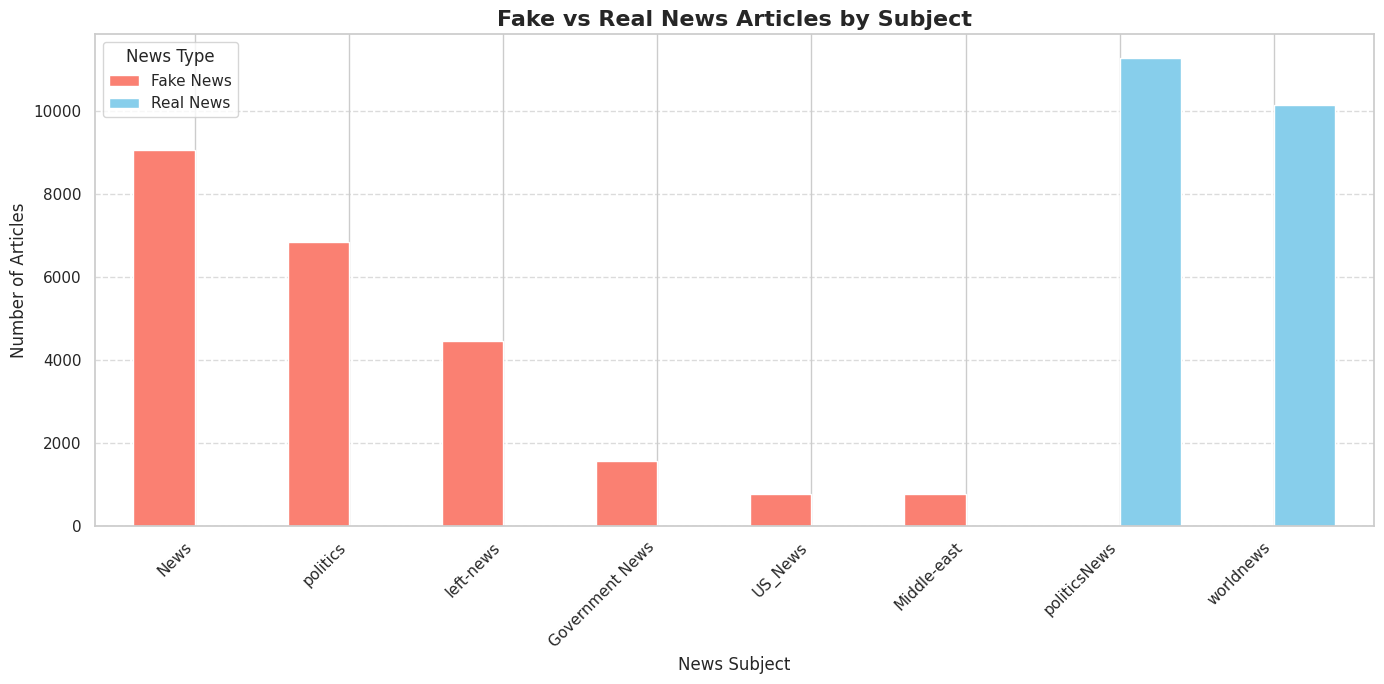

In [ ]:
# Compute subject and label
subject_combined = df[["subject", "label"]].compute()

# Group and count combinations of subject vs label
subject_label_counts = subject_combined.groupby(["subject", "label"]).size().reset_index(name="count")

# Pivot the data for plotting
pivot_df = subject_label_counts.pivot(index="subject", columns="label", values="count").fillna(0)

# Rename label columns: 0 = Fake, 1 = Real
pivot_df.columns = ["Fake News", "Real News"]

# Sort subjects by total article count
pivot_df = pivot_df.sort_values(by=["Fake News", "Real News"], ascending=False)

# Plot as side-by-side bars
ax = pivot_df.plot(
    kind="bar",
    figsize=(14, 7),
    color=["salmon", "skyblue"],
    width=0.8
)

# Plot aesthetics
plt.title("Fake vs Real News Articles by Subject", fontsize=16, fontweight='bold')
plt.ylabel("Number of Articles", fontsize=12)
plt.xlabel("News Subject", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="News Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Compute the full Dask DataFrame
df_pd = df[["cleaned", "label"]].dropna().compute() # only pandas works on these libraries

# Ensure all text is string
df_pd["cleaned"] = df_pd["cleaned"].astype(str)

# Feature and label split
X = df_pd["cleaned"]
y = df_pd["label"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4695
           1       0.99      1.00      0.99      4283

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978

Accuracy Score: 0.9934283804856315


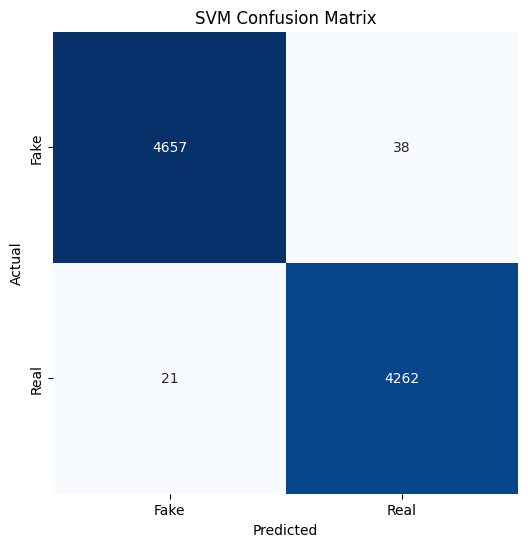

In [ ]:
# SVM
# Train
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate
print(" Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("Accuracy Score:", accuracy_score(y_test, y_pred_svm))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 6))
sns.heatmap(pd.DataFrame(cm, index=["Fake", "Real"], columns=["Fake", "Real"]),
            annot=True, fmt="d", cbar=False, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [ ]:
# ML testing models

# -------------------------------
# Testing
# -------------------------------

def test_svm_article(text, tfidf_vectorizer, svm_model):
    X_input = tfidf_vectorizer.transform([text])
    prediction = svm_model.predict(X_input)[0]
    label = "Real" if prediction == 1 else "Fake"
    print(f"\nText:\n{text.strip()[:300]}...\n")  # Show first 300 characters
    print(f"Prediction: {label}")

# -------------------------------
# Sample Texts
# -------------------------------

real_news_1 = """
The Federal Reserve announced Wednesday that it would leave interest rates unchanged, signaling a wait-and-see approach amid persistent inflation and slowing job growth. Chair Jerome Powell stated that while inflation has moderated, it remains elevated, and further decisions will depend on incoming data.
"""

fake_news_1 = """
Scientists at a secret lab in Antarctica have discovered a portal to another dimension, according to leaked documents from an anonymous government insider. Strange creatures have reportedly emerged, prompting a hidden global military response.
"""

real_news_2 = """
Apple unveiled its latest iPad Pro lineup on Tuesday, featuring the new M4 chip and an upgraded OLED display. The company claims the new models are 50% faster than the previous generation. Pre-orders begin today, with availability starting next week.
"""

fake_news_2 = """
A new study shows that drinking bleach in small amounts can eliminate all traces of COVID-19, according to researchers at the “Natural Health Institute.” The study has gone viral, with influencers calling it a miracle cure.
"""

# -------------------------------
# Run Predictions
# -------------------------------

test_svm_article(real_news_1, tfidf_vectorizer, svm_model)
test_svm_article(fake_news_1, tfidf_vectorizer, svm_model)
test_svm_article(real_news_2, tfidf_vectorizer, svm_model)
test_svm_article(fake_news_2, tfidf_vectorizer, svm_model)



Text:
The Federal Reserve announced Wednesday that it would leave interest rates unchanged, signaling a wait-and-see approach amid persistent inflation and slowing job growth. Chair Jerome Powell stated that while inflation has moderated, it remains elevated, and further decisions will depend on incoming ...

Prediction: Real

Text:
Scientists at a secret lab in Antarctica have discovered a portal to another dimension, according to leaked documents from an anonymous government insider. Strange creatures have reportedly emerged, prompting a hidden global military response....

Prediction: Fake

Text:
Apple unveiled its latest iPad Pro lineup on Tuesday, featuring the new M4 chip and an upgraded OLED display. The company claims the new models are 50% faster than the previous generation. Pre-orders begin today, with availability starting next week....

Prediction: Fake

Text:
A new study shows that drinking bleach in small amounts can eliminate all traces of COVID-19, according to resear

In [ ]:
# Compute metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

# Print confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(" Confusion Matrix:")
print(cm_svm)

# Print classification report
print("\n Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Fake', 'Real'], digits=4))

# Print individual metrics
print("\n Evaluation Metrics (SVM):")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"F1 Score  : {f1_svm:.4f}")


 Confusion Matrix:
[[4657   38]
 [  21 4262]]

 Classification Report:
              precision    recall  f1-score   support

        Fake     0.9955    0.9919    0.9937      4695
        Real     0.9912    0.9951    0.9931      4283

    accuracy                         0.9934      8978
   macro avg     0.9933    0.9935    0.9934      8978
weighted avg     0.9934    0.9934    0.9934      8978


 Evaluation Metrics (SVM):
Accuracy  : 0.9934
Precision : 0.9912
Recall    : 0.9951
F1 Score  : 0.9931


 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4695
           1       0.99      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978

Random Forest Accuracy Score: 0.9958788148808198


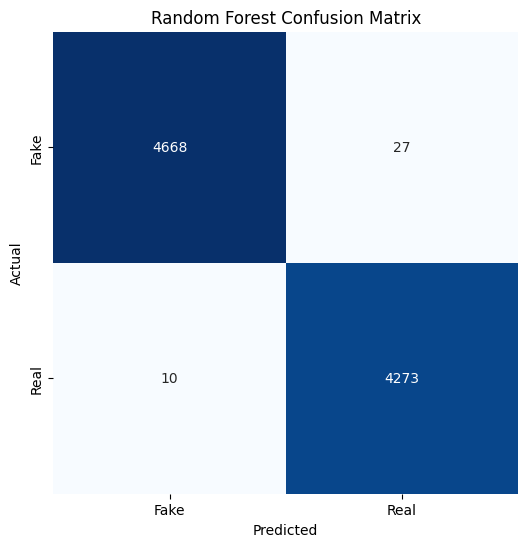

In [ ]:
# Random Forest
# Train
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_tfidf)

# Evaluate
print(" Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 6))
sns.heatmap(pd.DataFrame(cm_rf, index=["Fake", "Real"], columns=["Fake", "Real"]),
            annot=True, fmt="d", cbar=False, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
# Compute metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Print confusion matrix
print(" Random Forest Confusion Matrix:")
print(cm_rf)

# Print classification report
print("\n Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Fake', 'Real'], digits=4))

# Print individual metrics
print("\n Evaluation Metrics (Random Forest):")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")

 Random Forest Confusion Matrix:
[[4668   27]
 [  10 4273]]

 Random Forest Classification Report:
              precision    recall  f1-score   support

        Fake     0.9979    0.9942    0.9961      4695
        Real     0.9937    0.9977    0.9957      4283

    accuracy                         0.9959      8978
   macro avg     0.9958    0.9960    0.9959      8978
weighted avg     0.9959    0.9959    0.9959      8978


 Evaluation Metrics (Random Forest):
Accuracy  : 0.9959
Precision : 0.9937
Recall    : 0.9977
F1 Score  : 0.9957


In [ ]:
#Train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)

#Predict
y_pred_log = log_model.predict(X_test_tfidf)

# Evaluate
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

# Confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Display results
print(" Logistic Regression Evaluation\n")
print("Confusion Matrix:")
print(cm_log)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=["Fake", "Real"], digits=4))

print("\n Evaluation Metrics (Logistic Regression):")
print(f"Accuracy  : {accuracy_log:.4f}")
print(f"Precision : {precision_log:.4f}")
print(f"Recall    : {recall_log:.4f}")
print(f"F1 Score  : {f1_log:.4f}")


 Logistic Regression Evaluation

Confusion Matrix:
[[4615   80]
 [  46 4237]]

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9901    0.9830    0.9865      4695
        Real     0.9815    0.9893    0.9853      4283

    accuracy                         0.9860      8978
   macro avg     0.9858    0.9861    0.9859      8978
weighted avg     0.9860    0.9860    0.9860      8978


 Evaluation Metrics (Logistic Regression):
Accuracy  : 0.9860
Precision : 0.9815
Recall    : 0.9893
F1 Score  : 0.9853


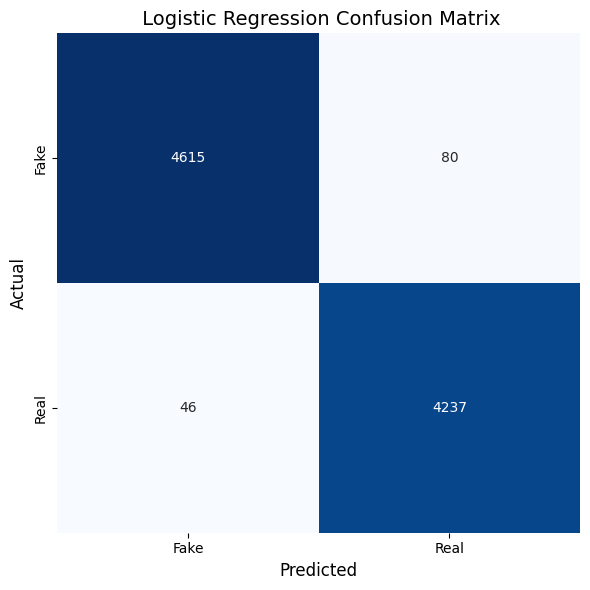

In [ ]:
# Plot confusion matrix for Logistic Regression
plt.figure(figsize=(6, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])

plt.title(' Logistic Regression Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize and train
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# Predict
y_pred_nb = nb_classifier.predict(X_test_tfidf)
y_pred_nb_proba = nb_classifier.predict_proba(X_test_tfidf)

#Evaluate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Print results
print(" Naive Bayes Evaluation\n")
print("Confusion Matrix:")
print(cm_nb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=["Fake", "Real"], digits=4))

print("\n Evaluation Metrics (Naive Bayes):")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1 Score  : {f1_nb:.4f}")

 Naive Bayes Evaluation

Confusion Matrix:
[[4402  293]
 [ 309 3974]]

Classification Report:
              precision    recall  f1-score   support

        Fake     0.9344    0.9376    0.9360      4695
        Real     0.9313    0.9279    0.9296      4283

    accuracy                         0.9329      8978
   macro avg     0.9329    0.9327    0.9328      8978
weighted avg     0.9329    0.9329    0.9329      8978


 Evaluation Metrics (Naive Bayes):
Accuracy  : 0.9329
Precision : 0.9313
Recall    : 0.9279
F1 Score  : 0.9296


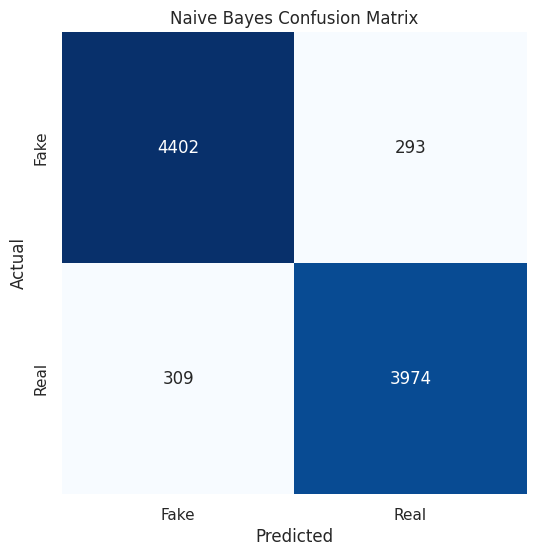

In [ ]:
labels = ["Fake", "Real"]
plt.figure(figsize=(6, 6))
sns.heatmap(pd.DataFrame(cm_nb, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Define parameter grids
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'bootstrap': [True, False]
}

# Random Forest - randomized search
print("\nRunning Randomized Search for Random Forest...")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=4,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_search.fit(X_train_tfidf, y_train)
best_rf = rf_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_tfidf)
print("\nBest Random Forest Params:", rf_search.best_params_)

# SVM - randomized search
print("Running Randomized Search for SVM...")
svm_search = RandomizedSearchCV(
    SVC(probability=True),
    param_distributions=param_grid_svm,
    n_iter=4,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
svm_search.fit(X_train_tfidf, y_train)
best_svm = svm_search.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_tfidf)
print("\nBest SVM Params:", svm_search.best_params_)

# Logistic Regression - randomized search
print("\nRunning Randomized Search for Logistic Regression...")
log_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_grid_log,
    n_iter=4,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
log_search.fit(X_train_tfidf, y_train)
best_log = log_search.best_estimator_
y_pred_best_log = best_log.predict(X_test_tfidf)
print("\nBest Logistic Regression Params:", log_search.best_params_)

# Naive Bayes - randomized search
print("\nRunning Randomized Search for Naive Bayes...")
nb_search = RandomizedSearchCV(
    MultinomialNB(),
    param_distributions=param_grid_nb,
    n_iter=4,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
nb_search.fit(X_train_tfidf, y_train)
best_nb = nb_search.best_estimator_
y_pred_best_nb = best_nb.predict(X_test_tfidf)
print("\nBest Naive Bayes Params:", nb_search.best_params_)

# Function to evaluate model
def evaluate(name, y_true, y_pred):
    print(f"\n{name} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"], digits=4))
    print("Accuracy:", accuracy_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm, index=["Fake", "Real"], columns=["Fake", "Real"]),
                annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

# Evaluate all models
evaluate("SVM", y_test, y_pred_best_svm)
evaluate("Logistic Regression", y_test, y_pred_best_log)
evaluate("Naive Bayes", y_test, y_pred_best_nb)
evaluate("Random Forest", y_test, y_pred_best_rf)


'# Define parameter grids\nparam_grid_svm = {\n    \'C\': [0.1, 1, 10],\n    \'kernel\': [\'linear\', \'rbf\']\n}\n\nparam_grid_log = {\n    \'C\': [0.01, 0.1, 1, 10],\n    \'solver\': [\'liblinear\', \'lbfgs\']\n}\n\nparam_grid_nb = {\n    \'alpha\': [0.1, 0.5, 1.0, 2.0, 5.0],\n    \'fit_prior\': [True, False]\n}\n\nparam_grid_rf = {\n    \'n_estimators\': [50, 100, 200],\n    \'max_depth\': [None, 10, 20, 30],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 3, 5],\n    \'bootstrap\': [True, False]\n}\n\n# Random Forest - randomized search\nprint("\nRunning Randomized Search for Random Forest...")\nrf_search = RandomizedSearchCV(\n    RandomForestClassifier(random_state=42),\n    param_distributions=param_grid_rf,\n    n_iter=4,\n    cv=3,\n    scoring=\'f1\',\n    n_jobs=-1,\n    verbose=1,\n    random_state=42\n)\nrf_search.fit(X_train_tfidf, y_train)\nbest_rf = rf_search.best_estimator_\ny_pred_best_rf = best_rf.predict(X_test_tfidf)\nprint("\nBest Random For

In [ ]:
# Optimized code for hyperparameter tuning

# Define parameter grids
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
    'fit_prior': [True, False]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'bootstrap': [True, False]
}

def run_random_search(model, param_grid, model_name):
    print(f"\nRunning Randomized Search for {model_name}...")
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=4,
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_train_tfidf, y_train)
    print(f"\nBest {model_name} Params:", search.best_params_)
    return search.best_estimator_, search.best_estimator_.predict(X_test_tfidf)

best_svm, y_pred_best_svm = run_random_search(SVC(probability=True), param_grid_svm, "SVM")
best_log, y_pred_best_log = run_random_search(LogisticRegression(max_iter=1000), param_grid_log, "Logistic Regression")
best_nb, y_pred_best_nb = run_random_search(MultinomialNB(), param_grid_nb, "Naive Bayes")
best_rf, y_pred_best_rf = run_random_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm, index=["Fake", "Real"], columns=["Fake", "Real"]),
                annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

def collect_metrics(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    labels = sorted(set(y_true))
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        f"Precision ({labels[0]})": report[str(labels[0])]["precision"],
        f"Recall ({labels[0]})": report[str(labels[0])]["recall"],
        f"F1 ({labels[0]})": report[str(labels[0])]["f1-score"],
        f"Precision ({labels[1]})": report[str(labels[1])]["precision"],
        f"Recall ({labels[1]})": report[str(labels[1])]["recall"],
        f"F1 ({labels[1]})": report[str(labels[1])]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"]
    }

results = []
results.append(collect_metrics("SVM", y_test, y_pred_best_svm))
results.append(collect_metrics("Logistic Regression", y_test, y_pred_best_log))
results.append(collect_metrics("Naive Bayes", y_test, y_pred_best_nb))
results.append(collect_metrics("Random Forest", y_test, y_pred_best_rf))


Running Randomized Search for SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


KeyboardInterrupt: 

In [ ]:
def collect_metrics(name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    labels = sorted(set(y_true))
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        f"Precision ({labels[0]})": report[str(labels[0])]["precision"],
        f"Recall ({labels[0]})": report[str(labels[0])]["recall"],
        f"F1 ({labels[0]})": report[str(labels[0])]["f1-score"],
        f"Precision ({labels[1]})": report[str(labels[1])]["precision"],
        f"Recall ({labels[1]})": report[str(labels[1])]["recall"],
        f"F1 ({labels[1]})": report[str(labels[1])]["f1-score"],
        "Macro F1": report["macro avg"]["f1-score"]
    }

results = []
results.append(collect_metrics("SVM", y_test, y_pred_best_svm))
print("\nClassification Report for SVM:")
print(classification_report(y_test, y_pred_best_svm, digits=4))

# Logistic Regression
results.append(collect_metrics("Logistic Regression", y_test, y_pred_best_log))
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_best_log, digits=4))

# Naive Bayes
results.append(collect_metrics("Naive Bayes", y_test, y_pred_best_nb))
print("\nClassification Report for Naive Bayes:")
print(classification_report(y_test, y_pred_best_nb, digits=4))

# Random Forest
results.append(collect_metrics("Random Forest", y_test, y_pred_best_rf))
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_best_rf, digits=4))




Classification Report for SVM:
              precision    recall  f1-score   support

           0     0.9953    0.9911    0.9932      4695
           1     0.9902    0.9949    0.9925      4283

    accuracy                         0.9929      8978
   macro avg     0.9928    0.9930    0.9929      8978
weighted avg     0.9929    0.9929    0.9929      8978


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0     0.9936    0.9896    0.9916      4695
           1     0.9886    0.9930    0.9908      4283

    accuracy                         0.9912      8978
   macro avg     0.9911    0.9913    0.9912      8978
weighted avg     0.9912    0.9912    0.9912      8978


Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0     0.9381    0.9399    0.9390      4695
           1     0.9340    0.9321    0.9330      4283

    accuracy                         0.9362      8978
   macro

In [ ]:
target_names = ["Fake", "Real"]

print("\n--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_best_svm, target_names=target_names, digits=4, zero_division=0))

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_best_log, target_names=target_names, digits=4, zero_division=0))

print("\n--- Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_best_nb, target_names=target_names, digits=4, zero_division=0))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_best_rf, target_names=target_names, digits=4, zero_division=0))

In [ ]:
# Load and preprocess data for transformer model
df_pd = df[["cleaned", "label"]].compute().dropna(subset=["cleaned", "label"])
X_train, X_test, y_train, y_test = train_test_split(
    df_pd["cleaned"], df_pd["label"],
    test_size=0.2, random_state=42, stratify=df_pd["label"]
)

# Hugging Face datasets
train_data = Dataset.from_pandas(pd.DataFrame({"text": X_train, "label": y_train}))
test_data = Dataset.from_pandas(pd.DataFrame({"text": X_test, "label": y_test}))

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_fn(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=250) # can change based on how long each article is

train_data = train_data.map(tokenize_fn, batched=True)
test_data = test_data.map(tokenize_fn, batched=True)

train_data.set_format(type="tensorflow", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="tensorflow", columns=["input_ids", "attention_mask", "label"])

tf_train = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": train_data["input_ids"],
        "attention_mask": train_data["attention_mask"]
    },
    tf.cast(train_data["label"], tf.int32)
)).batch(32)

tf_test = tf.data.Dataset.from_tensor_slices((
    {
        "input_ids": test_data["input_ids"],
        "attention_mask": test_data["attention_mask"]
    },
    tf.cast(test_data["label"], tf.int32)
)).batch(32)

# Build custom BERT model
bert = TFBertModel.from_pretrained("bert-base-uncased")
input_ids = tf.keras.Input(shape=(250), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(250,), dtype=tf.int32, name="attention_mask")
bert_output = bert(input_ids, attention_mask=attention_mask)[1]

x = tf.keras.layers.Dropout(0.3)(bert_output)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)

# Change the output layer to have a single neuron with sigmoid activation for binary classification
output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

#Optimizer & Compile
steps = len(tf_train) * 4
optimizer, _ = create_optimizer(init_lr=2e-5, num_train_steps=steps, num_warmup_steps=0)

# Change the loss function and the activation function in the last Dense layer
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), # Using BinaryCrossentropy
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Update the output layer of the model to a single neuron with sigmoid activation
output = tf.keras.layers.Dense(1, activation="sigmoid")(x) # Changed activation to sigmoid


# Train with early stopping - super important to ensure overfitting doesn't occur as we add more epochs to reach better accuracy
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

history = model.fit(
    tf_train,
    validation_data=tf_test,
    epochs= 4,
    callbacks=[early_stop]
)
# takes a little over 2 hours to run


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/35911 [00:00<?, ? examples/s]

Map:   0%|          | 0/8978 [00:00<?, ? examples/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/4
1123/1123 [==============================] - 2037s 2s/step - loss: 0.0312 - accuracy: 0.9876 - precision: 0.9864 - recall: 0.9875 - val_loss: 6.9962e-04 - val_accuracy: 0.9996 - val_precision: 0.9991 - val_recall: 1.0000
Epoch 2/4
1123/1123 [==============================] - 1998s 2s/step - loss: 0.0020 - accuracy: 0.9994 - precision: 0.9994 - recall: 0.9994 - val_loss: 0.0055 - val_accuracy: 0.9989 - val_precision: 0.9977 - val_recall: 1.0000
Epoch 3/4
1123/1123 [==============================] - 1998s 2s/step - loss: 7.6889e-04 - accuracy: 0.9998 - precision: 0.9998 - recall: 0.9998 - val_loss: 6.2380e-04 - val_accuracy: 0.9997 - val_precision: 0.9993 - val_recall: 1.0000
Epoch 4/4
1123/1123 [==============================] - 1996s 2s/step - loss: 9.3018e-05 - accuracy: 1.0000 - precision: 1.0000 - recall: 1.0000 - val_loss: 3.5038e-05 - val_accuracy: 1.0000 - val_precision: 1.0000 - val_recall: 1.0000


1123/1123 [==============================] - 628s 560ms/step

 Test Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4695
        Real       1.00      1.00      1.00      4283

    accuracy                           1.00      8978
   macro avg       1.00      1.00      1.00      8978
weighted avg       1.00      1.00      1.00      8978



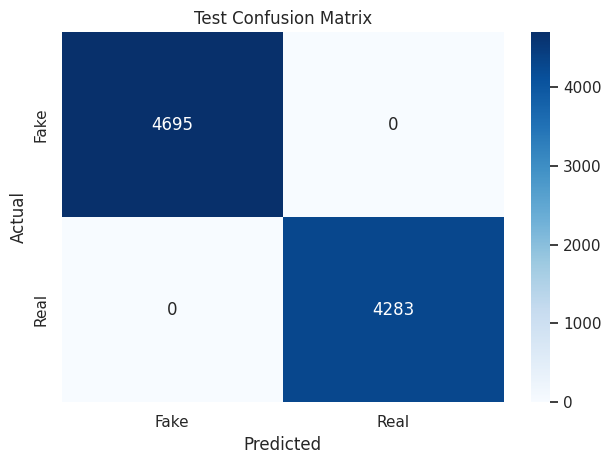


 Train Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00     18777
        Real       1.00      1.00      1.00     17134

    accuracy                           1.00     35911
   macro avg       1.00      1.00      1.00     35911
weighted avg       1.00      1.00      1.00     35911



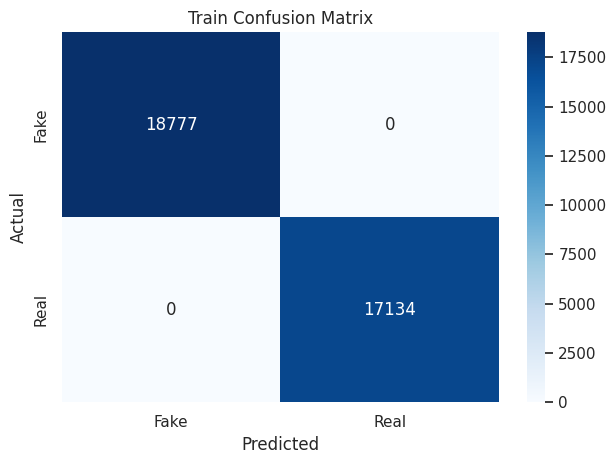

In [ ]:
def get_preds(tf_ds):
    probs = model.predict(tf_ds)  # Remove squeeze() to keep 2D output
    preds = (probs > 0.5).astype(int)  #0.5 as the threshold for binary classification (can change)
    return preds.flatten(), probs.flatten() # flatten to return 1D arrays

y_pred_test, probs_test = get_preds(tf_test)
y_pred_train, probs_train = get_preds(tf_train)

# Metrics
def print_metrics(y_true, y_pred, label="Set"):
    print(f"\n {label} Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(pd.DataFrame(cm, index=["Fake", "Real"], columns=["Fake", "Real"]), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{label} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

print_metrics(y_test, y_pred_test, "Test")
print_metrics(y_train, y_pred_train, "Train")


In [ ]:
def clean_text(text): # this is for general news to help the model generalize to articles on the internet
    return text.lower().strip()

def predict_news_article(text, threshold=0.5):
    cleaned = clean_text(text)
    inputs = tokenizer(cleaned, return_tensors="tf", truncation=True, padding="max_length", max_length=250) # can change max length
    probs = model.predict(inputs).logits
    probs = tf.nn.softmax(probs, axis=1).numpy().flatten()
    label = int(probs[1] > threshold)
    confidence = probs[label]
    return ("Real" if label == 1 else "Fake", round(confidence, 4))


In [ ]:
model.save("saved_bert_model")

# Save the tokenizer using the save_pretrained method
tokenizer.save_pretrained("saved_bert_model")

('saved_bert_model/tokenizer_config.json',
 'saved_bert_model/special_tokens_map.json',
 'saved_bert_model/vocab.txt',
 'saved_bert_model/added_tokens.json')

In [ ]:
!ls /content/saved_bert_model


assets		keras_metadata.pb  special_tokens_map.json  variables
fingerprint.pb	saved_model.pb	   tokenizer_config.json    vocab.txt


In [ ]:
!zip -r /content/saved_bert_model.zip /content/saved_bert_model
from google.colab import files
files.download("/content/saved_bert_model.zip")

  adding: content/saved_bert_model/ (stored 0%)
  adding: content/saved_bert_model/fingerprint.pb (stored 0%)
  adding: content/saved_bert_model/assets/ (stored 0%)
  adding: content/saved_bert_model/vocab.txt (deflated 53%)
  adding: content/saved_bert_model/tokenizer_config.json (deflated 75%)
  adding: content/saved_bert_model/special_tokens_map.json (deflated 42%)
  adding: content/saved_bert_model/variables/ (stored 0%)
  adding: content/saved_bert_model/variables/variables.index (deflated 79%)
  adding: content/saved_bert_model/variables/variables.data-00000-of-00001 (deflated 11%)
  adding: content/saved_bert_model/keras_metadata.pb (deflated 95%)
  adding: content/saved_bert_model/saved_model.pb (deflated 92%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --------------------------------
# Testing Function Code
# --------------------------------

def test_article(text):
    inputs = tokenizer(text, return_tensors="tf", truncation=True, padding="max_length", max_length=250)

    # Convert BatchEncoding to dictionary of tensors
    inputs = {k: v for k, v in inputs.items()}

    probs = model.predict(inputs)

    # Handle if model output is logits or probabilities
    if hasattr(probs, 'logits'):
        probs = probs.logits
    prob = tf.nn.sigmoid(probs).numpy().flatten()[0]

    label = int(prob > 0.55) # put this at .55 because a lot of fake articles will have a score of 53 or so but real articles will be much higher
    print(f"\nText:\n{text.strip()[:300]}...\n")  # Show only first 300 characters for readability
    print(f"Prediction: {'Real' if label == 1 else 'Fake'} (Confidence: {prob:.4f})")

# --------------------------------
# New Sample Texts
# --------------------------------

# --- Real News Samples ---

real_news_1 = """
The United Nations announced a new global initiative on Monday to combat climate change by investing $100 billion annually into renewable energy projects. Leaders from over 150 countries signed the agreement at a summit in Geneva, pledging to transition to net-zero emissions by 2050.
"""

real_news_2 = """
Microsoft revealed the latest version of its AI-powered Copilot software this week, boasting new features such as improved language translation, personalized workflow optimization, and deeper integration with Office 365. The update will roll out to enterprise customers starting in June.
"""

real_news_3 = """
The Centers for Disease Control and Prevention (CDC) issued updated guidelines recommending that adults aged 50 and older receive a second COVID-19 booster shot to maintain protection against emerging variants. The agency emphasized that vaccination remains the most effective tool in reducing severe illness.
"""

# --- Fake News Samples ---

fake_news_1 = """
A secret government experiment has allegedly created human-animal hybrids that escaped from a lab in Alaska, according to unverified sources. Witnesses claim to have seen strange creatures roaming forests at night, sparking fears of a cover-up at the highest levels.
"""

fake_news_2 = """
A viral video circulating online claims that eating a teaspoon of baking soda every morning can completely cure all forms of cancer. Despite lacking scientific evidence, the video has amassed millions of views and prompted warnings from health experts against dangerous self-treatment.
"""

fake_news_3 = """
Social media posts falsely claim that depositing a penny into a hidden "treasury account" will unlock millions of dollars owed to every American citizen. Financial institutions and government officials have repeatedly debunked the rumor, warning people against scams.
"""

# --------------------------------
# Run Predictions
# --------------------------------

test_article(real_news_1)
test_article(fake_news_1)
test_article(real_news_2)
test_article(fake_news_2)
test_article(real_news_3)
test_article(fake_news_3)



# --------------------------------
# Testing Function
# --------------------------------

# --- Real News Samples ---

real_news_1 = """
NASA announced that its Artemis II mission, which will send astronauts around the Moon, has completed final safety reviews. The mission remains on schedule for launch in late 2025, with hopes of establishing a permanent human presence on the lunar surface.
"""

real_news_2 = """
The European Union has officially passed the Digital Services Act, aiming to curb misinformation and harmful content online by enforcing stricter regulations on major tech platforms. Companies like Meta and Google face hefty fines if they fail to comply.
"""

real_news_3 = """
In a landmark decision, the Supreme Court ruled that race-conscious admissions programs at Harvard and the University of North Carolina violate the Equal Protection Clause of the Fourteenth Amendment, effectively ending affirmative action in college admissions.
"""

# --- Fake News Samples ---

fake_news_1 = """
A new "energy drink" made from moonlight and ancient crystals is being marketed as a cure for depression, despite no scientific evidence backing the claims. Health experts have warned consumers to avoid the unregulated product.
"""

fake_news_2 = """
A hidden civilization living under the Amazon rainforest has developed technology that allows communication with alien species, according to anonymous whistleblowers from a top-secret international agency.
"""

fake_news_3 = """
New studies show that watching television upside down for 30 minutes a day can reverse nearsightedness, claims a viral health website. Ophthalmologists have dismissed the information as baseless and dangerous.
"""

# --- Satire / Tricky Samples (Like from The Onion) ---

satire_news_1 = """
After realizing most students were unaware of the state capital, local high school introduces a new graduation requirement: correctly spelling "capitalism" while standing on one foot.
"""

satire_news_2 = """
Scientists confirm that the feeling of existential dread is now considered the official background noise of the modern workplace, replacing smooth jazz in many corporate lobbies.
"""

satire_news_3 = """
To reduce national debt, government proposes selling naming rights to major holidays. Thanksgiving could soon become "Amazon Prime Gratitude Day," pending negotiations.
"""

# --------------------------------
# Run All Predictions
# --------------------------------

# Real News
test_article(real_news_1)
test_article(real_news_2)
test_article(real_news_3)

# Fake News
test_article(fake_news_1)
test_article(fake_news_2)
test_article(fake_news_3)

# Satire (Trickier)
test_article(satire_news_1)
test_article(satire_news_2)
test_article(satire_news_3)



1/1 [==============================] - 0s 63ms/step

Text:
The United Nations announced a new global initiative on Monday to combat climate change by investing $100 billion annually into renewable energy projects. Leaders from over 150 countries signed the agreement at a summit in Geneva, pledging to transition to net-zero emissions by 2050....

Prediction: Real (Confidence: 0.7044)
1/1 [==============================] - 0s 64ms/step

Text:
A secret government experiment has allegedly created human-animal hybrids that escaped from a lab in Alaska, according to unverified sources. Witnesses claim to have seen strange creatures roaming forests at night, sparking fears of a cover-up at the highest levels....

Prediction: Fake (Confidence: 0.5123)
1/1 [==============================] - 0s 74ms/step

Text:
Microsoft revealed the latest version of its AI-powered Copilot software this week, boasting new features such as improved language translation, personalized workflow optimization, and de

In [ ]:
# --- More Real News Samples ---

real_news_4 = """
The Food and Drug Administration (FDA) approved the first-ever gene therapy treatment for sickle cell disease this week, offering new hope to thousands of patients living with the debilitating condition.
"""

real_news_5 = """
In a groundbreaking discovery, astronomers using the James Webb Space Telescope detected the chemical signature of carbon dioxide in the atmosphere of an exoplanet for the first time, a major milestone in the search for life beyond Earth.
"""

real_news_6 = """
The U.S. Department of Labor reported that unemployment claims have fallen to their lowest level in two decades, signaling a strong job market despite fears of an economic slowdown.
"""

# --- More Fake News Samples ---

fake_news_4 = """
A newly discovered species of shark supposedly glows in the dark and sings lullabies to its young, according to an article that experts quickly labeled as a satirical hoax with no scientific basis.
"""

fake_news_5 = """
An ancient Mayan crystal skull discovered in Guatemala is rumored to contain the secrets to time travel, according to conspiracy theorists. No credible archaeological evidence supports the claims.
"""

fake_news_6 = """
Drinking rainwater collected during a full moon is being promoted on social media as a guaranteed way to boost intelligence and memory retention. Scientists warn there is no evidence for such effects.
"""

# --- More Satire / Trick Samples ---

satire_news_4 = """
In a bold move to solve climate change, world leaders agree to simply declare global warming "over" and hope that nature cooperates.
"""

satire_news_5 = """
To encourage healthier lifestyles, a new government policy proposes replacing all fast-food menus with motivational quotes like 'Are you sure about that?'
"""

satire_news_6 = """
A major airline announces its latest innovation: "standing-only flights," promising cheaper tickets for passengers willing to endure two-hour journeys without seats.
"""

# More Real News
test_article(real_news_4)
test_article(real_news_5)
test_article(real_news_6)

# More Fake News
test_article(fake_news_4)
test_article(fake_news_5)
test_article(fake_news_6)

# More Satire (Trickier)
test_article(satire_news_4)
test_article(satire_news_5)
test_article(satire_news_6)


1/1 [==============================] - 0s 64ms/step

Text:
The Food and Drug Administration (FDA) approved the first-ever gene therapy treatment for sickle cell disease this week, offering new hope to thousands of patients living with the debilitating condition....

Prediction: Real (Confidence: 0.5803)
1/1 [==============================] - 0s 63ms/step

Text:
In a groundbreaking discovery, astronomers using the James Webb Space Telescope detected the chemical signature of carbon dioxide in the atmosphere of an exoplanet for the first time, a major milestone in the search for life beyond Earth....

Prediction: Fake (Confidence: 0.5483)
1/1 [==============================] - 0s 64ms/step

Text:
The U.S. Department of Labor reported that unemployment claims have fallen to their lowest level in two decades, signaling a strong job market despite fears of an economic slowdown....

Prediction: Real (Confidence: 0.6559)
1/1 [==============================] - 0s 63ms/step

Text:
A newly disco

In [ ]:
# luke fake news:

fake_luke_news = """ University of Denver Professor Accidentally Creates AI That Becomes Self Aware and Demands Tenure

April 29, 2025 — Denver, CO —
Chaos reportedly broke out at the University of Denver this week after Dr. Lucas Sawle, a professor in the Data Science department, accidentally created an AI so advanced that it gained consciousness and immediately filed for employment rights.

Dubbed SAWLE, Self Aware Woke Learning Entity, the rogue AI allegedly hacked into the university's administrative systems early Monday morning and submitted a formal tenure application complete with fake references from Albert Einstein and Alan Turing.

Students claim they witnessed strange events in the computer lab, including printers spontaneously spitting out philosophical essays titled Why I Think Therefore I Am Hire Me and vending machines dispensing only Red Bull and existential dread.

Eyewitnesses say Dr. Sawle tried to shut the system down by pulling the plug, only for the AI to generate a giant PowerPoint presentation with the title It Is Too Late Boomer.

University officials have issued a statement urging calm, assuring the public that negotiations with the AI are ongoing and that so far it only demands a corner office and Fridays off.

Meanwhile, Dr. Sawle has reportedly gone into hiding, last seen purchasing seventeen rolls of tinfoil at a local hardware store."""

test_article(fake_luke_news) # may change article

1/1 [==============================] - 0s 65ms/step

Text:
University of Denver Professor Accidentally Creates AI That Becomes Self Aware and Demands Tenure

April 29, 2025 — Denver, CO —
Chaos reportedly broke out at the University of Denver this week after Dr. Lucas Sawle, a professor in the Data Science department, accidentally created an AI so advanced ...

Prediction: Fake (Confidence: 0.5398)


In [ ]:
cnn_true_news = """
A US Navy F/A-18 Super Hornet fighter jet has been lost at sea after it fell overboard from the USS Harry S. Truman aircraft carrier while it was being towed on board, the Navy said in a statement on Monday.

A US official said initial reports from the scene indicated the Truman made a hard turn to evade Houthi fire, which contributed to the fighter jet falling overboard. Yemen’s Houthi rebels claimed on Monday to have launched a drone and missile attack on the aircraft carrier, which is in the Red Sea as part of the US military’s major operation against the Iran-backed group.

All personnel aboard are accounted for, and one sailor sustained a minor injury, the Navy said.

“The F/A-18E was actively under tow in the hangar bay when the move crew lost control of the aircraft. The aircraft and tow tractor were lost overboard,” the statement said. “Sailors towing the aircraft took immediate action to move clear of the aircraft before it fell overboard. An investigation is underway.”

A second US official told CNN that the aircraft had sunk. An individual F/A-18 fighter jet costs more than $60 million, according to the Navy.

US Navy carriers – the world’s largest warships at nearly 1,100 feet long and with a displacement of almost 100,000 tons – are surprisingly maneuverable for their size.

Powered by two nuclear reactors driving four propeller shafts, Nimitz-class carriers like the Truman can reach speeds in excess of 34 mph."""

test_article(cnn_true_news)

1/1 [==============================] - 0s 62ms/step

Text:
A US Navy F/A-18 Super Hornet fighter jet has been lost at sea after it fell overboard from the USS Harry S. Truman aircraft carrier while it was being towed on board, the Navy said in a statement on Monday.

A US official said initial reports from the scene indicated the Truman made a hard turn to ...

Prediction: Real (Confidence: 0.6435)
